🔴 **LIVE DEMO**

✅  **Install dependencies**

---

*IInstalls the minimum packages needed for the demo.*

In [1]:
!pip install -q transformers Pillow torch

✅  **Imports**

---

*Loads all libraries needed for image loading, model inference, and displaying results.*

In [2]:
import torch
import time
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from transformers import BlipProcessor, BlipForConditionalGeneration

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")


Device: cpu


✅  **Mount Google Drive**

---

*Connects to Drive to load the trained model checkpoint
saved by 02_model_training.ipynb.*

In [3]:
from google.colab import drive
drive.mount("/content/drive")

SAVE_DIR = Path("/content/drive/MyDrive/caption_project")
print("Drive mounted. Loading model from:", SAVE_DIR / "best_model")

Mounted at /content/drive
Drive mounted. Loading model from: /content/drive/MyDrive/caption_project/best_model


✅  **Load trained model from checkpoint**

---

*Loads the best model saved during training directly from Google Drive. No retraining needed.*

In [4]:
processor = BlipProcessor.from_pretrained(SAVE_DIR / "best_model")
model     = BlipForConditionalGeneration.from_pretrained(
                SAVE_DIR / "best_model").to(DEVICE)
model.eval()

print("✅ Model loaded successfully from checkpoint.")
print(f"   Parameters : {sum(p.numel() for p in model.parameters()):,}")


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


✅ Model loaded successfully from checkpoint.
   Parameters : 247,444,600


✅  **Interactive demo**

---

*Upload any image from your computer and instantly see the top 3 captions the model generates along with generation time and model settings.*

   IMAGE CAPTION GENERATOR — LIVE DEMO
   ITAI 1378 | Group 22600

Upload any image to generate a caption:



Saving 931e24eae9f9a58fd8cc25f4773b906e-xxlarge.jpeg to 931e24eae9f9a58fd8cc25f4773b906e-xxlarge.jpeg


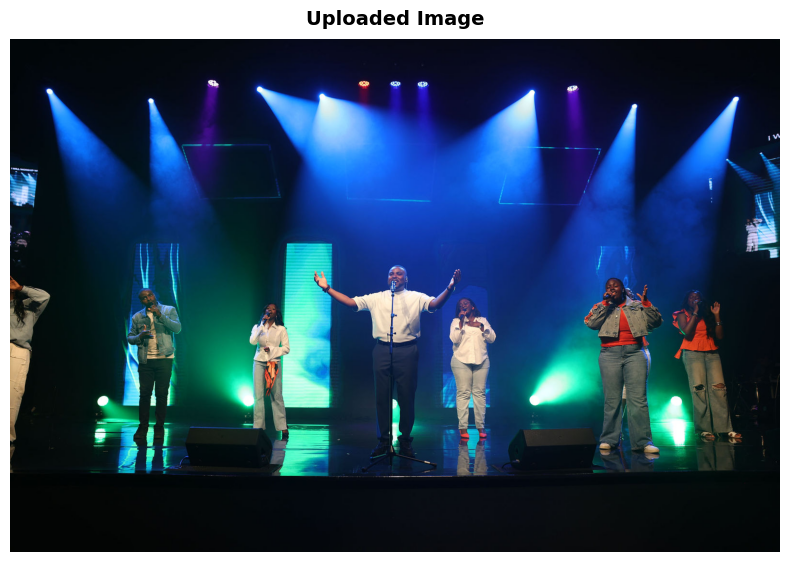


⏳ Generating caption…

  ✅ BEST CAPTION:
  📸 a photo showing a group of people on a stage.

  🔁 Alternative captions:
  2. a photo showing a group of people on stage.
  3. a photo showing a group of people on the stage.

  ⏱  Generated in 24.17 seconds
  🤖 Model  : Salesforce/blip-image-captioning-base
  📊 Beams  : 4 | Max tokens : 40 | Min length : 8


In [5]:
from google.colab import files
import IPython.display as display

print("=" * 50)
print("   IMAGE CAPTION GENERATOR — LIVE DEMO")
print("   ITAI 1378 | Group 22600")
print("=" * 50)
print("\nUpload any image to generate a caption:\n")

uploaded = files.upload()

for fname, data in uploaded.items():
    with open(fname, "wb") as f:
        f.write(data)

    img = Image.open(fname).convert("RGB")

    # Display image inline
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    ax.imshow(img)
    ax.axis("off")
    ax.set_title("Uploaded Image", fontsize=14, fontweight="bold", pad=10)
    plt.tight_layout()
    plt.show()

    print("\n⏳ Generating caption…\n")

    # Time the generation
    start  = time.time()
    inputs = processor(
        images=img,
        text="a photo showing",   # prompt steers toward natural captions
        return_tensors="pt"
    ).to(DEVICE)

    with torch.no_grad():
        # Beam search generates top 3 caption candidates
        out_ids = model.generate(
            **inputs,
            num_beams=4,
            max_new_tokens=40,
            min_length=8,
            length_penalty=1.2,
            repetition_penalty=1.3,
            num_return_sequences=3,
            early_stopping=True,
        )
    elapsed = time.time() - start

    # Decode all 3 captions from token IDs to readable text
    captions = [
        processor.decode(ids, skip_special_tokens=True)
        for ids in out_ids
    ]

    # Print results
    print("=" * 50)
    print(f"  ✅ BEST CAPTION:")
    print(f"  📸 {captions[0]}")
    print("=" * 50)
    print(f"\n  🔁 Alternative captions:")
    for i, cap in enumerate(captions[1:], 2):
        print(f"  {i}. {cap}")
    print(f"\n  ⏱  Generated in {elapsed:.2f} seconds")
    print(f"  🤖 Model  : Salesforce/blip-image-captioning-base")
    print(f"  📊 Beams  : 4 | Max tokens : 40 | Min length : 8")
    print("=" * 50)


✅  **Batch demo on sample images**

---

*Runs the model on multiple images at once and displays them in a grid*

Upload multiple images for batch captioning:


Saving bentley-bentley-toddlers-and-kids-balance-bike-68132_700x700.webp to bentley-bentley-toddlers-and-kids-balance-bike-68132_700x700.webp
Saving GettyImages-1407832840.webp to GettyImages-1407832840.webp
Saving julie-ertz-kick.webp to julie-ertz-kick.webp
  ✅ bentley-bentley-toddlers-and-kids-balance-bike-68132_700x700.webp: a photo showing a little boy riding a bike.
  ✅ GettyImages-1407832840.webp: a photo showing a variety of donuts and pastries.
  ✅ julie-ertz-kick.webp: a photo showing a girl kicking a soccer ball.


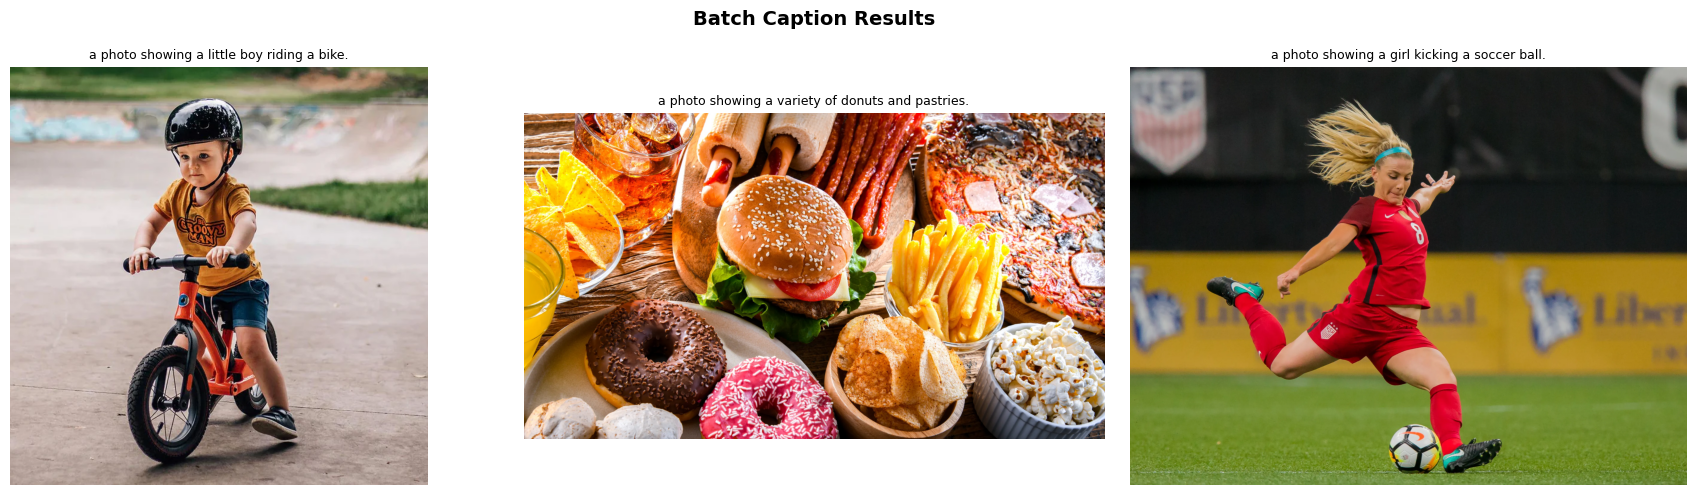

Batch results saved to Drive.


In [6]:
print("Upload multiple images for batch captioning:")
uploaded_batch = files.upload()

images   = []
captions = []

for fname, data in uploaded_batch.items():
    with open(fname, "wb") as f:
        f.write(data)

    img    = Image.open(fname).convert("RGB")
    inputs = processor(
        images=img,
        text="a photo showing",
        return_tensors="pt"
    ).to(DEVICE)

    with torch.no_grad():
        out_ids = model.generate(
            **inputs,
            num_beams=4,
            max_new_tokens=40,
            min_length=8,
            early_stopping=True,
        )

    caption = processor.decode(out_ids[0], skip_special_tokens=True)
    images.append(img)
    captions.append(caption)
    print(f"  ✅ {fname}: {caption}")

# Display all images in a grid with captions
n   = len(images)
fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
if n == 1:
    axes = [axes]

for ax, img, cap in zip(axes, images, captions):
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(cap, fontsize=9, wrap=True)

plt.suptitle("Batch Caption Results", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR / "batch_demo_results.png", dpi=150)
plt.show()
print("Batch results saved to Drive.")